In [1]:
! pip install pandas sqlalchemy


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [3]:
! pip install plotly


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import os
from dotenv import load_dotenv
import pandas as pd
from sqlalchemy import create_engine
import psycopg
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
    

In [5]:
load_dotenv()
engine = create_engine(os.environ["DATABASE_URL"])
df = pd.read_sql("SELECT * FROM pts_trips_yearly_2025", engine)

In [6]:
df

,id,dt,pickup_hr,pickup_municipality,pickup_community_council,pickup_ward,dropoff_municipality,dropoff_community_council,dropoff_ward,trips_total,fare_avg,waittime_avg,distance_avg,duration_avg,loaded_at
0,1,2025-12-30,2025-12-30 17:00:00-05:00,Toronto,Toronto and East York,04 - Parkdale-High Park,Toronto,Etobicoke York,03 - Etobicoke-Lakeshore,38,17.63,4.29,7.82,16.35,2026-04-28 01:51:54.233190+00:00
1,2,2025-12-30,2025-12-30 17:00:00-05:00,Toronto,North York,08 - Eglinton-Lawrence,Toronto,North York,18 - Willowdale,38,18.52,7.37,8.61,22.86,2026-04-28 01:51:54.233190+00:00
2,3,2025-12-30,2025-12-30 17:00:00-05:00,Mississauga,Not in Toronto,Not in Toronto,Toronto,Toronto and East York,10 - Spadina-Fort York,38,52.88,4.87,29.68,44.71,2026-04-28 01:51:54.233190+00:00
3,4,2025-12-30,2025-12-30 17:00:00-05:00,Mississauga,Not in Toronto,Not in Toronto,Toronto,Etobicoke York,01 - Etobicoke North,37,21.40,4.05,13.28,18.81,2026-04-28 01:51:54.233190+00:00
4,5,2025-12-30,2025-12-30 17:00:00-05:00,Toronto,Toronto and East York,19 - Beaches-East York,Toronto,Toronto and East York,10 - Spadina-Fort York,37,23.60,3.76,10.66,26.51,2026-04-28 01:51:54.233190+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3203088,3203089,2025-12-31,2025-12-31 23:00:00-05:00,Burlington,Not in Toronto,Not in Toronto,Toronto,Etobicoke York,Not included elsewhere,1,59.96,2.00,48.80,36.00,2026-04-28 01:51:54.233190+00:00
3203089,3203090,2025-12-31,2025-12-31 23:00:00-05:00,Oshawa,Not in Toronto,Not in Toronto,Toronto,Etobicoke York,Not included elsewhere,1,74.35,3.00,66.20,52.00,2026-04-28 01:51:54.233190+00:00
3203090,3203091,2025-12-31,2025-12-31 23:00:00-05:00,Whitby,Not in Toronto,Not in Toronto,Toronto,Toronto and East York,Not included elsewhere,1,58.14,5.00,45.50,33.00,2026-04-28 01:51:54.233190+00:00
3203091,3203092,2025-12-31,2025-12-31 23:00:00-05:00,Toronto,Scarborough,Not included elsewhere,Burlington,Not in Toronto,Not in Toronto,1,86.88,8.00,72.30,47.00,2026-04-28 01:51:54.233190+00:00


In [26]:
unique_pickup_municipality = df['pickup_municipality'].unique()
unique_pickup_community_council = df['pickup_community_council'].unique()
unique_pickup_ward = df['pickup_ward'].unique()

print("Unique pickup_municipality:", unique_pickup_municipality)
print("Unique pickup_community_council:", unique_pickup_community_council)
print("Unique pickup_ward:", unique_pickup_ward)

Unique pickup_municipality: <StringArray>
[           'Toronto',        'Mississauga',            'Markham',
            'Vaughan',    'Pearson Airport',           'Brampton',
      'Richmond Hill',          'Pickering', 'Other Municipality',
           'Oakville',               'Ajax',             'Whitby',
             'Oshawa',         'Burlington']
Length: 14, dtype: str
Unique pickup_community_council: <StringArray>
['Toronto and East York',            'North York',        'Not in Toronto',
        'Etobicoke York',           'Scarborough']
Length: 5, dtype: str
Unique pickup_ward: <StringArray>
[      '04 - Parkdale-High Park',        '08 - Eglinton-Lawrence',
                'Not in Toronto',        '19 - Beaches-East York',
       '12 - Toronto-St. Paul's',              '06 - York Centre',
        '05 - York South-Weston',   '25 - Scarborough-Rouge Park',
          '01 - Etobicoke North',          '15 - Don Valley West',
 '07 - Humber River-Black Creek',         '17 - Don Valle

In [18]:
df['pickup_community_council'].value_counts()

pickup_community_council
Toronto and East York    995095
North York               657655
Etobicoke York           535009
Not in Toronto           514749
Scarborough              500585
Name: count, dtype: int64

In [23]:
def get_pickup_location(row):
    if row['pickup_ward'] not in ['Not in Toronto', 'Not included elsewhere']:
        return row['pickup_ward']
    else:
        if row['pickup_community_council'] == 'Not in Toronto':
            return row['pickup_municipality']
        else:
            return row['pickup_community_council']


def get_dropoff_location(row):
    if row['dropoff_ward'] not in ['Not in Toronto', 'Not included elsewhere']:
        return row['dropoff_ward']
    else:
        if row['dropoff_community_council'] == 'Not in Toronto':
            return row['dropoff_municipality']
        else:
            return row['dropoff_community_council']
   

df['pick_up_location'] = df.apply(get_pickup_location, axis=1)
df['drop_off_location'] = df.apply(get_dropoff_location, axis=1)
df['pickup_dropoff'] = df['pick_up_location'] + " -> " + df['drop_off_location']

### Weekly Pickup/Dropoff Raw Table

Display the weekly pickup/dropoff raw table for inspection before adding SQL logic.

In [ ]:
# Build and display the weekly raw pickup/dropoff table for inspection.
df['dt'] = pd.to_datetime(df['dt'])
weekly_pickup_dropoff_raw = (
    df.assign(
        week_start=(df['dt'] - pd.to_timedelta(df['dt'].dt.dayofweek, unit='D')).dt.normalize(),
        week_end=lambda x: x['week_start'] + pd.Timedelta(days=6),
    )
    .groupby(['week_start', 'week_end', 'pickup_dropoff'], as_index=False)['trips_total']
    .sum()
    .sort_values(['week_start', 'trips_total', 'pickup_dropoff'], ascending=[True, False, True])
    .reset_index(drop=True)
)

display(weekly_pickup_dropoff_raw)

In [31]:
df

,id,dt,pickup_hr,pickup_municipality,pickup_community_council,pickup_ward,dropoff_municipality,dropoff_community_council,dropoff_ward,trips_total,fare_avg,waittime_avg,distance_avg,duration_avg,loaded_at,pick_up_location,drop_off_location,pickup_dropoff
0,1,2025-12-30,2025-12-30 17:00:00-05:00,Toronto,Toronto and East York,04 - Parkdale-High Park,Toronto,Etobicoke York,03 - Etobicoke-Lakeshore,38,17.63,4.29,7.82,16.35,2026-04-28 01:51:54.233190+00:00,04 - Parkdale-High Park,03 - Etobicoke-Lakeshore,04 - Parkdale-High Park -> 03 - Etobicoke-Lake...
1,2,2025-12-30,2025-12-30 17:00:00-05:00,Toronto,North York,08 - Eglinton-Lawrence,Toronto,North York,18 - Willowdale,38,18.52,7.37,8.61,22.86,2026-04-28 01:51:54.233190+00:00,08 - Eglinton-Lawrence,18 - Willowdale,08 - Eglinton-Lawrence -> 18 - Willowdale
2,3,2025-12-30,2025-12-30 17:00:00-05:00,Mississauga,Not in Toronto,Not in Toronto,Toronto,Toronto and East York,10 - Spadina-Fort York,38,52.88,4.87,29.68,44.71,2026-04-28 01:51:54.233190+00:00,Mississauga,10 - Spadina-Fort York,Mississauga -> 10 - Spadina-Fort York
3,4,2025-12-30,2025-12-30 17:00:00-05:00,Mississauga,Not in Toronto,Not in Toronto,Toronto,Etobicoke York,01 - Etobicoke North,37,21.40,4.05,13.28,18.81,2026-04-28 01:51:54.233190+00:00,Mississauga,01 - Etobicoke North,Mississauga -> 01 - Etobicoke North
4,5,2025-12-30,2025-12-30 17:00:00-05:00,Toronto,Toronto and East York,19 - Beaches-East York,Toronto,Toronto and East York,10 - Spadina-Fort York,37,23.60,3.76,10.66,26.51,2026-04-28 01:51:54.233190+00:00,19 - Beaches-East York,10 - Spadina-Fort York,19 - Beaches-East York -> 10 - Spadina-Fort York
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3203088,3203089,2025-12-31,2025-12-31 23:00:00-05:00,Burlington,Not in Toronto,Not in Toronto,Toronto,Etobicoke York,Not included elsewhere,1,59.96,2.00,48.80,36.00,2026-04-28 01:51:54.233190+00:00,Burlington,Etobicoke York,Burlington -> Etobicoke York
3203089,3203090,2025-12-31,2025-12-31 23:00:00-05:00,Oshawa,Not in Toronto,Not in Toronto,Toronto,Etobicoke York,Not included elsewhere,1,74.35,3.00,66.20,52.00,2026-04-28 01:51:54.233190+00:00,Oshawa,Etobicoke York,Oshawa -> Etobicoke York
3203090,3203091,2025-12-31,2025-12-31 23:00:00-05:00,Whitby,Not in Toronto,Not in Toronto,Toronto,Toronto and East York,Not included elsewhere,1,58.14,5.00,45.50,33.00,2026-04-28 01:51:54.233190+00:00,Whitby,Toronto and East York,Whitby -> Toronto and East York
3203091,3203092,2025-12-31,2025-12-31 23:00:00-05:00,Toronto,Scarborough,Not included elsewhere,Burlington,Not in Toronto,Not in Toronto,1,86.88,8.00,72.30,47.00,2026-04-28 01:51:54.233190+00:00,Scarborough,Burlington,Scarborough -> Burlington


In [33]:
# Only show data for years 2024 and 2025

# Make sure 'dt' is datetime type
df['dt'] = pd.to_datetime(df['dt'])

# Filter only dates in 2024 and 2025
df_years = df[df['dt'].dt.year.isin([2024, 2025])].copy()

# Get the start and end of week for each date (Monday to Sunday)
week_start = df_years['dt'] - pd.to_timedelta(df_years['dt'].dt.weekday, unit='d')
week_end = week_start + pd.Timedelta(days=6)

# Format week label as requested
df_years['week'] = week_start.dt.strftime('%Y-%m-%d') + '_' + week_end.dt.strftime('%Y-%m-%d')

# Aggregate groupby week, pickup_dropoff, and date; count trips
weekly_daily_agg = (
    df_years.groupby(['week', 'pickup_dropoff', 'dt'])
      .size()
      .reset_index(name='trips_total')
)

weekly_daily_agg.head()

/var/folders/jg/9_bv1df548zdn0f7nkgy_2280000gn/T/ipykernel_38458/1930691135.py:10: Pandas4Warning: 'd' is deprecated and will be removed in a future version. Please use 'D' instead of 'd'.
  week_start = df_years['dt'] - pd.to_timedelta(df_years['dt'].dt.weekday, unit='d')


,week,pickup_dropoff,dt,trips_total
0,2024-12-30_2025-01-05,01 - Etobicoke North -> 01 - Etobicoke North,2025-01-01,24
1,2024-12-30_2025-01-05,01 - Etobicoke North -> 01 - Etobicoke North,2025-01-02,24
2,2024-12-30_2025-01-05,01 - Etobicoke North -> 01 - Etobicoke North,2025-01-03,24
3,2024-12-30_2025-01-05,01 - Etobicoke North -> 01 - Etobicoke North,2025-01-04,24
4,2024-12-30_2025-01-05,01 - Etobicoke North -> 01 - Etobicoke North,2025-01-05,24


In [34]:
weekly_daily_agg

,week,pickup_dropoff,dt,trips_total
0,2024-12-30_2025-01-05,01 - Etobicoke North -> 01 - Etobicoke North,2025-01-01,24
1,2024-12-30_2025-01-05,01 - Etobicoke North -> 01 - Etobicoke North,2025-01-02,24
2,2024-12-30_2025-01-05,01 - Etobicoke North -> 01 - Etobicoke North,2025-01-03,24
3,2024-12-30_2025-01-05,01 - Etobicoke North -> 01 - Etobicoke North,2025-01-04,24
4,2024-12-30_2025-01-05,01 - Etobicoke North -> 01 - Etobicoke North,2025-01-05,24
...,...,...,...,...
240528,2025-12-29_2026-01-04,Whitby -> Scarborough,2025-12-30,22
240529,2025-12-29_2026-01-04,Whitby -> Scarborough,2025-12-31,21
240530,2025-12-29_2026-01-04,Whitby -> Toronto and East York,2025-12-29,16
240531,2025-12-29_2026-01-04,Whitby -> Toronto and East York,2025-12-30,19


In [40]:
weekly_daily_agg.pickup_dropoff.unique()


<StringArray>
[         '01 - Etobicoke North -> 01 - Etobicoke North',
         '01 - Etobicoke North -> 02 - Etobicoke Centre',
      '01 - Etobicoke North -> 03 - Etobicoke-Lakeshore',
       '01 - Etobicoke North -> 04 - Parkdale-High Park',
        '01 - Etobicoke North -> 05 - York South-Weston',
              '01 - Etobicoke North -> 06 - York Centre',
 '01 - Etobicoke North -> 07 - Humber River-Black Creek',
        '01 - Etobicoke North -> 08 - Eglinton-Lawrence',
                '01 - Etobicoke North -> 09 - Davenport',
        '01 - Etobicoke North -> 10 - Spadina-Fort York',
 ...
                    '21 - Scarborough Centre -> Vaughan',
      '23 - Scarborough North -> 05 - York South-Weston',
      '23 - Scarborough North -> 08 - Eglinton-Lawrence',
        'Other Municipality -> 03 - Etobicoke-Lakeshore',
  '08 - Eglinton-Lawrence -> 24 - Scarborough-Guildwood',
         '12 - Toronto-St. Paul's -> Other Municipality',
       '14 - Toronto-Danforth -> 23 - Scarborough Nor

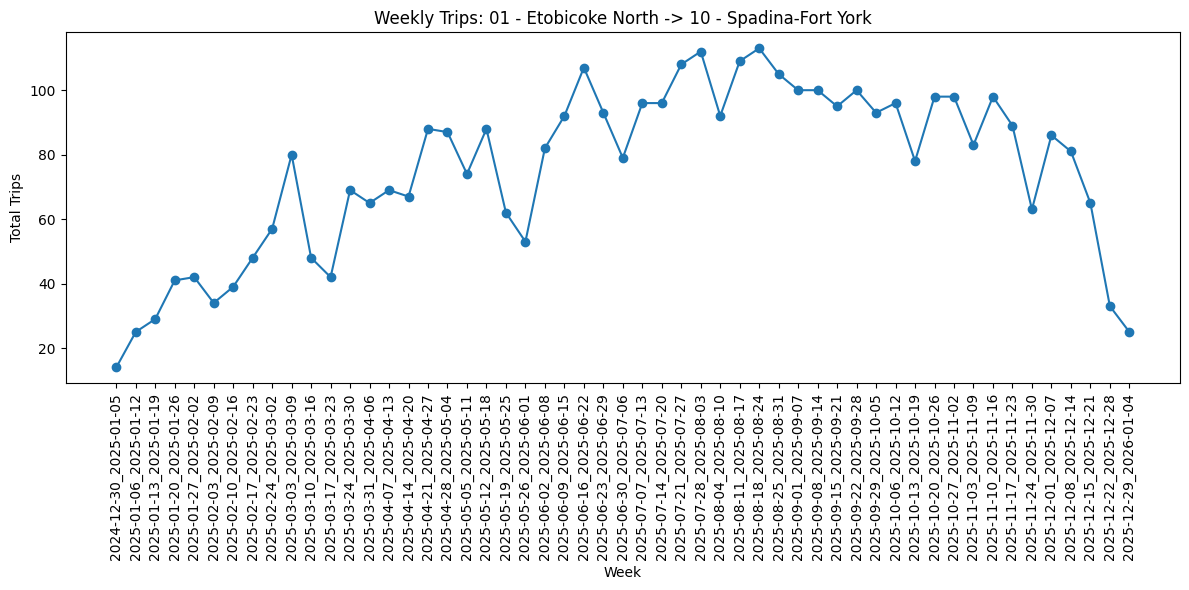

In [43]:
# Filter for the specific pickup_dropoff route
route_name = "01 - Etobicoke North -> 10 - Spadina-Fort York"
route_weekly = (
    weekly_daily_agg[weekly_daily_agg['pickup_dropoff'] == route_name]
    .groupby('week', as_index=False)['trips_total']
    .sum()
    .sort_values('week')
)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(route_weekly['week'], route_weekly['trips_total'], marker='o')
plt.xticks(rotation=90)
plt.xlabel('Week')
plt.ylabel('Total Trips')
plt.title(f"Weekly Trips: {route_name}")
plt.tight_layout()
plt.show()